# Machine Learning Pipelines and GridSearchCV

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
import seaborn as sns
from sklearn.metrics import confusion_matrix

<h3 style = 'color: red'>Train a model using pipeline</h3>

In [8]:
data = load_iris()
x, y = data.data, data.target
labels = data.target_names

<h3 style = 'color: red'>Instantiate a pipeline consisting of StandardScaler, PCA, and KNN</h3>

In [9]:
# step 1: standardize features
# step 2: reduce dimensions to 2 using PCA
# step 3: k-nearest neighbors classificaiton model
pipeline = Pipeline([('scaler', StandardScaler()),
                     ('pca', PCA(n_components = 2)),
                     ('knn', KNeighborsClassifier(n_neighbors = 5))])

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [11]:
pipeline.fit(x_train, y_train)
# measure the pipeline accuracy on the test data
test_score = pipeline.score(x_test, y_test)
print(f'{test_score:.3f}')

0.933


In [12]:
y_pred = pipeline.predict(x_test)

<h3 style = 'color: red'>generate the confusion matrix for the knn model</h3>

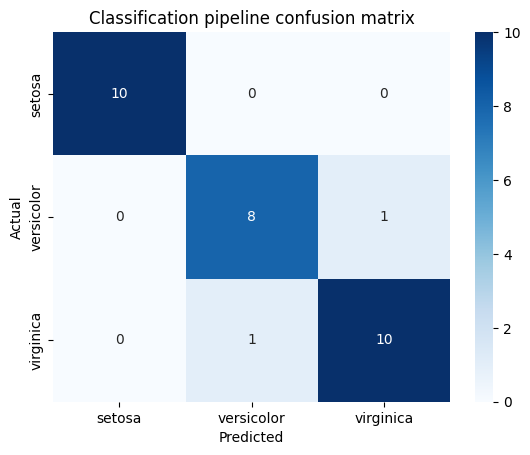

In [14]:
conf_matrix = confusion_matrix(y_test, y_pred)
# create a single plot for the confusion matrix
plt.figure()
sns.heatmap(conf_matrix, annot = True, cmap = 'Blues', fmt = 'd', xticklabels = labels, yticklabels = labels)
plt.title('Classification pipeline confusion matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

<h3 style = 'color: red'>Tune hyperparameters using a pipeline within cross-validation grid search</h3>

In [15]:
# instantiate the pipeline without specifying any parameters
pipeline = Pipeline([('scaler', StandardScaler()),
                     ('pca', PCA()),
                     ('knn', KNeighborsClassifier())])

In [16]:
# define a model parameter grid to search over
param_grid = {'pca__n_components': [2, 3],
              'knn__n_neighbors': [3, 5, 7]}
# to ensure the target is stratified, use scikit-learn's StratifiedKFold cross-validation class
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

In [18]:
# determine the best parameters
best_model = GridSearchCV(estimator = pipeline,
                          param_grid = param_grid,
                          cv = cv,
                          scoring = 'accuracy',
                          verbose = 2)

In [19]:
best_model.fit(x_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=3, pca__n_components=3; total time=   0.0s
[CV] END ............knn__n_neighbors=5, pca__n_components=2; total time=   0.0s
[CV] END ............knn__n_neighbors=5, pca__n_c

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('pca', PCA()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [3, 5, 7],
                         'pca__n_components': [2, 3]},
             scoring='accuracy', verbose=2)

In [22]:
test_score = best_model.score(x_test, y_test)
print(f'{test_score:0.3f}')

1.000


In [23]:
best_model.best_params_

{'knn__n_neighbors': 7, 'pca__n_components': 3}

<h3 style = 'color: red'>Plot the confusion matrix for the predictions on the test set</h3>

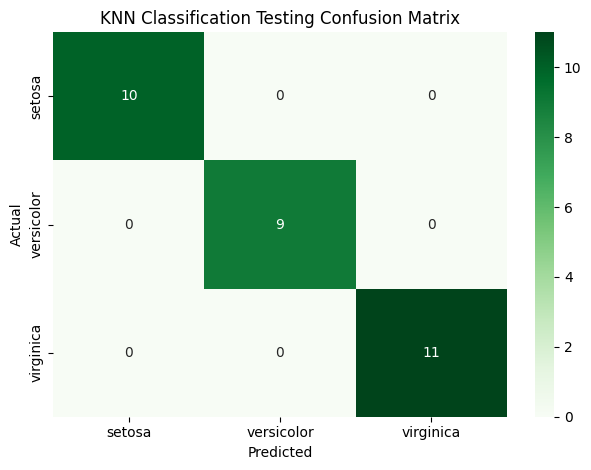

In [24]:
y_pred = best_model.predict(x_test)
# generate the confusion matrix for knn
conf_matrix = confusion_matrix(y_test, y_pred)
# create a single plot for the confusion matrix
plt.figure()
sns.heatmap(conf_matrix, annot = True, cmap = 'Greens', fmt = 'd', xticklabels = labels, yticklabels = labels)
plt.title('KNN Classification Testing Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()